In [2]:
import os
os.chdir(r"C:\Users\lalit\Documents\nyc-congestion-toll-impact")
print(os.getcwd())

C:\Users\lalit\Documents\nyc-congestion-toll-impact


In [4]:
import os
import duckdb
import pandas as pd

os.chdir(r"C:\Users\lalit\Documents\nyc-congestion-toll-impact")
pd.set_option("display.width", 200)

yoy = duckdb.sql("""
    WITH base AS (
        SELECT CASE WHEN trip_date < DATE '2025-01-01' THEN 'before' ELSE 'after' END AS period,
               company, trip_group,
               SUM(trips) AS trips,
               SUM(sum_rider_cost) / SUM(trips) AS avg_cost,
               SUM(sum_miles) / (SUM(sum_trip_seconds) / 3600) AS mph,
               SUM(sum_driver_pay) / (SUM(sum_trip_seconds) / 3600) AS driver_pay_hr,
               SUM(sum_wait_seconds) / SUM(wait_trips) / 60 AS wait_min
        FROM 'data/summary/*.parquet'
        WHERE (trip_date BETWEEN '2024-02-01' AND '2024-07-31')
           OR (trip_date BETWEEN '2025-02-01' AND '2025-07-31')
        GROUP BY ALL
    )
    SELECT a.company, a.trip_group,
           ROUND(100 * (a.trips / b.trips - 1), 1)                 AS trips_pct,
           ROUND(100 * (a.avg_cost / b.avg_cost - 1), 1)           AS cost_pct,
           ROUND(100 * (a.mph / b.mph - 1), 1)                     AS speed_pct,
           ROUND(100 * (a.driver_pay_hr / b.driver_pay_hr - 1), 1) AS pay_hr_pct,
           ROUND(a.wait_min - b.wait_min, 2)                       AS wait_change_min
    FROM base a JOIN base b USING (company, trip_group)
    WHERE a.period = 'after' AND b.period = 'before'
      AND a.company IN ('Uber', 'Lyft', 'Yellow')
    ORDER BY a.company, a.trip_group
""").df()

yoy

,company,trip_group,trips_pct,cost_pct,speed_pct,pay_hr_pct,wait_change_min
0,Lyft,boundary,12.4,1.7,-0.9,3.7,0.07
1,Lyft,entering,12.5,0.8,-0.0,4.2,0.08
2,Lyft,exiting,3.6,1.3,0.4,4.2,0.13
3,Lyft,inside,10.3,7.0,3.6,4.5,0.02
4,Lyft,outside,10.0,-3.4,-2.6,2.4,0.13
5,Uber,boundary,-10.9,11.8,2.8,7.0,0.06
6,Uber,entering,-11.1,13.1,3.4,8.0,0.39
7,Uber,exiting,-7.2,12.4,3.2,8.2,0.14
8,Uber,inside,-13.4,18.5,1.0,8.3,-0.10
9,Uber,outside,0.2,2.2,-0.8,3.0,0.37


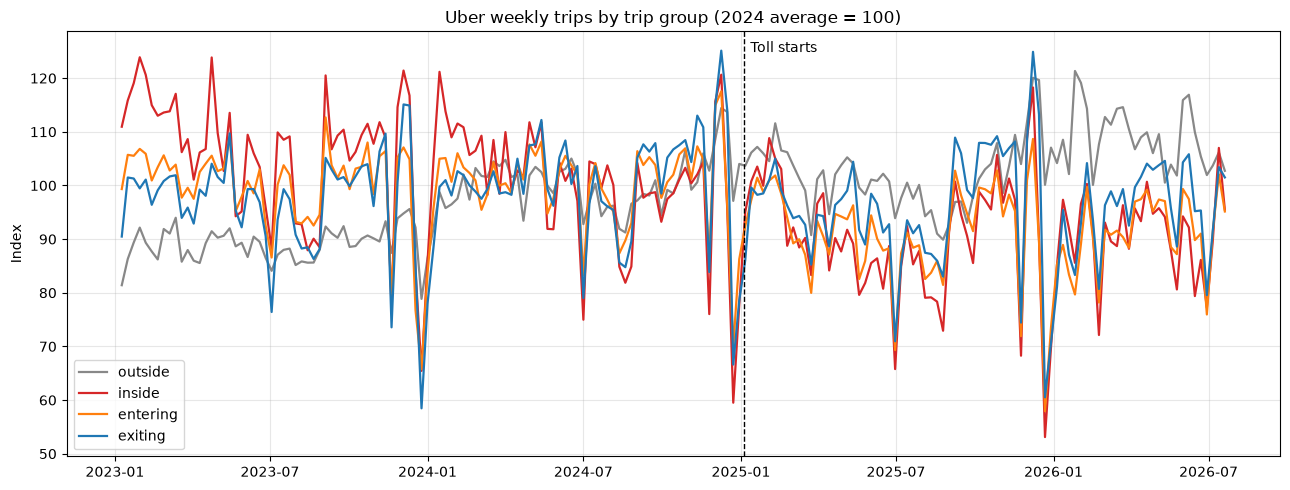

In [5]:
import matplotlib.pyplot as plt

weekly = duckdb.sql("""
    SELECT date_trunc('week', trip_date) AS week, trip_group, SUM(trips) AS trips
    FROM 'data/summary/*.parquet'
    WHERE company = 'Uber'
      AND trip_group IN ('inside', 'entering', 'exiting', 'outside')
      AND trip_date >= '2023-01-09' AND trip_date < '2026-07-27'
    GROUP BY ALL
""").df()

pivot = weekly.pivot(index="week", columns="trip_group", values="trips").sort_index()

# index each group to its 2024 average = 100, so all groups share one scale
base = pivot.loc["2024-01-01":"2024-12-31"].mean()
indexed = pivot / base * 100

fig, ax = plt.subplots(figsize=(13, 5))
for group, color in [("outside", "#888888"), ("inside", "#d62728"),
                     ("entering", "#ff7f0e"), ("exiting", "#1f77b4")]:
    ax.plot(indexed.index, indexed[group], label=group, color=color, lw=1.6)

ax.axvline(pd.Timestamp("2025-01-05"), color="black", ls="--", lw=1)
ax.text(pd.Timestamp("2025-01-12"), ax.get_ylim()[1] * 0.97, "Toll starts", fontsize=10)
ax.set_title("Uber weekly trips by trip group (2024 average = 100)")
ax.set_ylabel("Index")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/parallel_trends_uber.png", dpi=150)
plt.show()

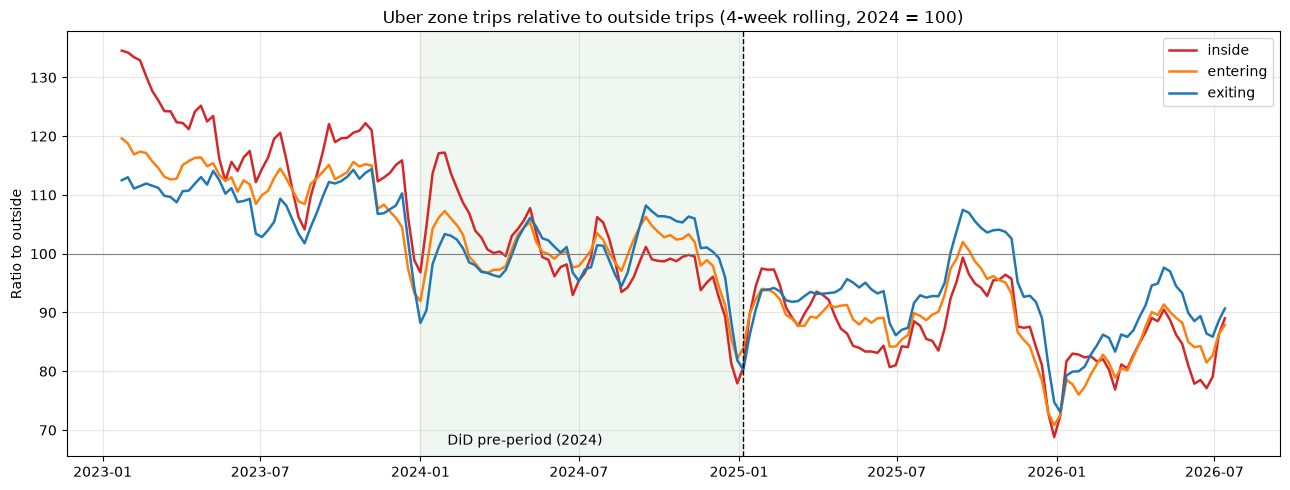

In [6]:
ratio = indexed[["inside", "entering", "exiting"]].div(indexed["outside"], axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
for group, color in [("inside", "#d62728"), ("entering", "#ff7f0e"), ("exiting", "#1f77b4")]:
    ax.plot(ratio.index, ratio[group].rolling(4, center=True).mean(),
            label=group, color=color, lw=1.8)

ax.axvline(pd.Timestamp("2025-01-05"), color="black", ls="--", lw=1)
ax.axhline(100, color="grey", lw=0.8)
ax.axvspan(pd.Timestamp("2024-01-01"), pd.Timestamp("2025-01-05"), color="green", alpha=0.06)
ax.text(pd.Timestamp("2024-02-01"), ax.get_ylim()[0] + 2, "DiD pre-period (2024)", fontsize=10)
ax.set_title("Uber zone trips relative to outside trips (4-week rolling, 2024 = 100)")
ax.set_ylabel("Ratio to outside")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/ratio_to_outside_uber.png", dpi=150)
plt.show()

In [8]:
import numpy as np
import statsmodels.formula.api as smf

d = duckdb.sql("""
    SELECT trip_date, trip_group, SUM(trips) AS trips
    FROM 'data/summary/*.parquet'
    WHERE company = 'Uber'
      AND trip_group IN ('inside', 'entering', 'exiting', 'outside')
      AND trip_date BETWEEN '2024-01-01' AND '2025-12-31'
    GROUP BY ALL
""").df()

d["trip_date"] = pd.to_datetime(d["trip_date"])
d["post"] = (d["trip_date"] >= "2025-01-05").astype(int)
d["log_trips"] = np.log(d["trips"])
d["dow"] = d["trip_date"].dt.dayofweek
d["week"] = d["trip_date"].dt.to_period("W").astype(str)
for g in ["inside", "entering", "exiting"]:
    d[f"{g}_post"] = ((d["trip_group"] == g) & (d["post"] == 1)).astype(int)

# weekday pattern of each zone group relative to outside (outside's is absorbed by the date effects)
d["group_dow"] = np.where(d["trip_group"] == "outside", "outside",
                          d["trip_group"] + "_" + d["dow"].astype(str))

model = smf.ols(
    "log_trips ~ inside_post + entering_post + exiting_post + C(group_dow) + C(trip_date)",
    data=d,
).fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(d["week"])[0]})

res = pd.DataFrame({"coef": model.params, "se": model.bse, "p_value": model.pvalues}) \
        .loc[["inside_post", "entering_post", "exiting_post"]]
res["effect_pct"] = (np.exp(res["coef"]) - 1) * 100
res["ci_low_pct"] = (np.exp(res["coef"] - 1.96 * res["se"]) - 1) * 100
res["ci_high_pct"] = (np.exp(res["coef"] + 1.96 * res["se"]) - 1) * 100
res.round(3)

,coef,se,p_value,effect_pct,ci_low_pct,ci_high_pct
inside_post,-0.119,0.027,0.000,-11.257,-15.805,-6.463
entering_post,-0.108,0.020,0.000,-10.200,-13.622,-6.642
exiting_post,-0.060,0.022,0.007,-5.837,-9.836,-1.660
